# Lee-Ready Trade Classification Validation

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Quantify how well the Lee-Ready algorithm recovers the aggressor side of
trades, using DataBento XNAS-ITCH MBO data (which carries the ground-truth
aggressor flag) as the benchmark.

## Learning Objectives

After completing this notebook, you will be able to:
- Reconstruct the LOB from DataBento MBO messages and align trades to the
  contemporaneous quote midpoint.
- Apply the Lee-Ready quote-test + tick-test cascade and compare its
  accuracy against the tick test alone.
- Read the per-day breakdown (NVDA, 5 trading days) and reproduce the ~16pp
  gap §3.4 reports between tick-only and Lee-Ready classification.

## Book reference

Section §3.4, *The Art of Sampling* — Lee-Ready subsection (Table 3.3).

## Prerequisites

- DataBento XNAS-ITCH MBO parquets at
  `data/equities/market/microstructure/market_by_order/{SYMBOL}/`
  (downloaded via `data/equities/market/microstructure/mbo_download.py`).

## Decision Time vs Exchange Time

This validation uses **exchange timestamps** for trade-quote alignment, which
matches the ground truth's timestamping. In live trading, observation delay
means the quote you could actually have seen at decision time lags the
exchange state — apply a conservative lag (~1ms co-located, ~10ms retail)
in any backtest that relies on this kind of classification.

---

## Setup

In [1]:
"""Lee-Ready Trade Classification Validation — validate Lee-Ready against DataBento ground truth aggressor labels."""

import warnings
from collections import Counter
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import polars as pl

# Import loader for MBO data
from data import load_mbo_data

# ML4T imports - path resolution
from utils.paths import get_output_dir
from utils.style import COLORS

In [2]:
SYMBOL = "NVDA"
MAX_ROWS = 0  # 0 = all rows per file
MAX_VALIDATION_DAYS = 5  # Number of days for multi-day validation

In [3]:
# Normalize MAX_ROWS: 0 means no limit
if MAX_ROWS == 0:
    MAX_ROWS = None
# Get file paths from the canonical loader (handles legacy/new path resolution)
data_files = load_mbo_data(symbols=[SYMBOL], list_files=True)
SYMBOL_DIR = data_files[0].parent if data_files else None
OUTPUT_DIR = get_output_dir(3, "algoseek")

# Check data availability (files already loaded via load_mbo_data)
print(f"Symbol: {SYMBOL}")
print(f"Data files: {len(data_files)}")
if data_files:
    print(f"First file: {data_files[0].name}")

Symbol: NVDA
Data files: 10
First file: xnas-itch-20241104.mbo.dbn.parquet


## 1. Load DataBento MBO Data

DataBento MBO format:
- `action`: A(Add), C(Cancel), F(Fill), M(Modify), T(Trade), R(Clear)
- `side`: B(Bid/Buy), A(Ask/Sell), N(None)
- `price`: Integer fixed-point (nanodollars, divide by 1e9)
- `size`: Order/trade size
- `order_id`: Unique order reference
- `timestamp`: Exchange timestamp

In [4]:
def load_databento_mbo(file_path: Path, max_rows: int | None = None) -> pl.DataFrame:
    """Load and normalize DataBento MBO data.

    Handles both file layouts the repo can produce: Download Center files carry a
    ``timestamp`` column, while the API downloader (``mbo_download.py``) carries
    ``ts_event``. We normalize to ``timestamp`` and filter regular trading hours in
    exchange-local time so the window is correct on either side of a DST change.
    """
    df = pl.read_parquet(file_path)

    # Apply row limit
    if max_rows is not None:
        df = df.head(max_rows)

    # Normalize the event-time column name (API files use `ts_event`).
    if "timestamp" not in df.columns and "ts_event" in df.columns:
        df = df.rename({"ts_event": "timestamp"})

    # DataBento timestamps are UTC; keep a UTC-naive column for downstream code.
    df = df.with_columns(pl.col("timestamp").cast(pl.Datetime("ns")))

    # Convert fixed-point prices to dollars if needed
    if "price" in df.columns and df["price"].max() > 1_000_000:
        df = df.with_columns((pl.col("price") / 1e9).alias("price"))

    # Filter to regular trading hours (09:30-16:00 America/New_York). Convert the
    # UTC instant to exchange-local time so the window is correct in both EDT and
    # EST: a fixed UTC window silently drops the final trading hour (or admits an
    # hour of pre-market) whenever the sample straddles a DST boundary.
    _et = pl.col("timestamp").dt.replace_time_zone("UTC").dt.convert_time_zone("America/New_York")
    df = df.filter(
        ((_et.dt.hour() > 9) | ((_et.dt.hour() == 9) & (_et.dt.minute() >= 30)))
        & (_et.dt.hour() < 16)
    )

    # Sort by timestamp. Note: Messages with identical timestamps may not have
    # a guaranteed order; DataBento sequence numbers could be used if available.
    return df.sort("timestamp")

In [5]:
# Load one day for validation
sample_df = None
if data_files:
    sample_df = load_databento_mbo(data_files[0], max_rows=MAX_ROWS)
    print(f"Loaded {len(sample_df):,} messages")

    # Action distribution
    action_counts = sample_df.group_by("action").len().sort("len", descending=True)
    print("\nAction distribution:")
    for row in action_counts.iter_rows():
        print(f"  {row[0]}: {row[1]:,}")

Loaded 8,722,992 messages

Action distribution:
  A: 4,271,991
  C: 4,091,800
  T: 195,420
  F: 163,781


## 2. Lee-Ready Classification with LOB Reconstruction

Lee-Ready algorithm (1991):
1. **Quote test**: Compare trade price to midpoint
   - Above midpoint → buy-initiated
   - Below midpoint → sell-initiated
2. **Tick test** (fallback when at midpoint):
   - Higher than previous trade → buy
   - Lower than previous trade → sell

Key implementation detail: We must maintain LOB state as we process trades
to get the correct midpoint at each trade time.

In [6]:
def _update_book(
    action: str,
    side: str,
    price: float,
    size: int,
    order_id: int,
    book: dict[str, Counter],
    order_registry: dict[int, dict],
) -> dict[str, Counter]:
    """Apply a book-affecting action (R/A/M/C/F) to the LOB state."""
    if action == "R":  # Clear book
        book = {"B": Counter(), "A": Counter()}
        order_registry.clear()

    elif action == "A":  # Add order
        order_registry[order_id] = {"side": side, "price": price, "size": size}
        book[side][price] += size

    elif action == "M":  # Modify order
        if order_id in order_registry:
            old = order_registry[order_id]
            book[old["side"]][old["price"]] -= old["size"]
            if book[old["side"]][old["price"]] <= 0:
                del book[old["side"]][old["price"]]
            order_registry[order_id] = {"side": side, "price": price, "size": size}
            book[side][price] += size

    elif action in ("C", "F"):  # Cancel or Fill
        if order_id in order_registry:
            reg = order_registry[order_id]
            book[reg["side"]][reg["price"]] -= size
            if book[reg["side"]][reg["price"]] <= 0:
                del book[reg["side"]][reg["price"]]
            reg["size"] -= size
            if reg["size"] <= 0:
                del order_registry[order_id]

    return book

### Apply Lee-Ready Classification
Quote test with tick test fallback for trade direction inference.

In [7]:
def _apply_lee_ready(
    price: float,
    book: dict[str, Counter],
    last_price: float | None,
    last_tick_dir: int,
) -> tuple[int, int]:
    """Apply Lee-Ready quote test + tick test fallback. Returns (classification, updated_tick_dir)."""
    if book["B"] and book["A"]:
        best_bid = max(book["B"].keys())
        best_ask = min(book["A"].keys())
        midpoint = (best_bid + best_ask) / 2

        # Quote test
        if price > midpoint:
            lee_ready = 1  # Buy
        elif price < midpoint:
            lee_ready = -1  # Sell
        else:
            # At midpoint - use tick test
            if last_price is not None:
                if price > last_price:
                    last_tick_dir = 1
                elif price < last_price:
                    last_tick_dir = -1
            lee_ready = last_tick_dir
    else:
        # No book - use tick test only
        if last_price is not None:
            if price > last_price:
                lee_ready = 1
            elif price < last_price:
                lee_ready = -1
            else:
                lee_ready = last_tick_dir
        else:
            lee_ready = 0

    return lee_ready, last_tick_dir

### Classify Trades via Lee-Ready
Walk through MBO messages, maintain book state, and classify each trade.

In [8]:
def classify_trades_lee_ready_databento(
    df: pl.DataFrame, show_progress: bool = True
) -> pl.DataFrame:
    """
    Classify trade direction using Lee-Ready on DataBento MBO data.

    Maintains LOB state while processing to get accurate midpoint at trade time.

    Parameters
    ----------
    df : pl.DataFrame
        DataBento MBO data with action, side, price, size, order_id, timestamp
    show_progress : bool
        Whether to show progress bar

    Returns
    -------
    pl.DataFrame
        Trades with columns: timestamp, price, size, ground_truth, lee_ready, correct
    """
    order_registry: dict[int, dict] = {}
    book: dict[str, Counter] = {"B": Counter(), "A": Counter()}
    classified_trades = []
    last_price = None
    last_tick_dir = 0

    cols_df = df.select(["timestamp", "action", "side", "price", "size", "order_id"])
    if show_progress:
        print(f"Processing {len(cols_df):,} messages...")

    for row in cols_df.iter_rows(named=True):
        action, side, price, size = row["action"], row["side"], row["price"], row["size"]
        order_id, ts = row["order_id"], row["timestamp"]

        if side == "N" and action != "T":
            continue

        if action in ("R", "A", "M", "C", "F"):
            book = _update_book(action, side, price, size, order_id, book, order_registry)

        elif action == "T":
            # Get ground truth (DataBento provides aggressor side)
            ground_truth = 1 if side == "B" else (-1 if side == "A" else 0)
            if ground_truth == 0:
                continue

            lee_ready, last_tick_dir = _apply_lee_ready(price, book, last_price, last_tick_dir)
            classified_trades.append(
                {
                    "timestamp": ts,
                    "price": price,
                    "size": size,
                    "ground_truth": ground_truth,
                    "lee_ready": lee_ready,
                    "correct": int(ground_truth == lee_ready),
                }
            )
            last_price = price

    print(f"Classified {len(classified_trades):,} trades")
    return pl.DataFrame(classified_trades)

## 3. Run Validation

In [9]:
results = None
if sample_df is not None and len(sample_df) > 1000:
    results = classify_trades_lee_ready_databento(sample_df)

    if len(results) > 0:
        # Compute accuracy
        accuracy = results["correct"].mean() * 100

        # Breakdown by ground truth
        buy_trades = results.filter(pl.col("ground_truth") == 1)
        sell_trades = results.filter(pl.col("ground_truth") == -1)

        buy_accuracy = buy_trades["correct"].mean() * 100 if len(buy_trades) > 0 else 0
        sell_accuracy = sell_trades["correct"].mean() * 100 if len(sell_trades) > 0 else 0

        print("\n" + "=" * 50)
        print("LEE-READY VALIDATION RESULTS")
        print("=" * 50)
        print(f"\nTotal trades classified: {len(results):,}")
        print(f"Overall accuracy: {accuracy:.2f}%")
        print("\nBy ground truth:")
        print(f"  Buy-initiated:  {buy_accuracy:.2f}% ({len(buy_trades):,} trades)")
        print(f"  Sell-initiated: {sell_accuracy:.2f}% ({len(sell_trades):,} trades)")

        # Confusion matrix
        true_pos_buy = results.filter(
            (pl.col("ground_truth") == 1) & (pl.col("lee_ready") == 1)
        ).height
        false_neg_buy = results.filter(
            (pl.col("ground_truth") == 1) & (pl.col("lee_ready") != 1)
        ).height
        true_pos_sell = results.filter(
            (pl.col("ground_truth") == -1) & (pl.col("lee_ready") == -1)
        ).height
        false_neg_sell = results.filter(
            (pl.col("ground_truth") == -1) & (pl.col("lee_ready") != -1)
        ).height

        print("\nConfusion matrix:")
        print(f"  True Buy  (GT=B, LR=B): {true_pos_buy:,}")
        print(f"  False Buy (GT=B, LR≠B): {false_neg_buy:,}")
        print(f"  True Sell (GT=A, LR=A): {true_pos_sell:,}")
        print(f"  False Sell(GT=A, LR≠A): {false_neg_sell:,}")

Processing 8,722,992 messages...


Classified 163,774 trades

LEE-READY VALIDATION RESULTS

Total trades classified: 163,774
Overall accuracy: 94.20%

By ground truth:
  Buy-initiated:  93.58% (83,223 trades)
  Sell-initiated: 94.84% (80,551 trades)

Confusion matrix:
  True Buy  (GT=B, LR=B): 77,881
  False Buy (GT=B, LR≠B): 5,342
  True Sell (GT=A, LR=A): 76,397
  False Sell(GT=A, LR≠A): 4,154


## 4. Multi-Day Validation

Run validation across multiple days to get robust statistics.

In [10]:
def validate_multiple_days(
    data_files: list,
    max_files: int | None = None,
    show_progress: bool = True,
    max_rows_per_file: int | None = None,
) -> pl.DataFrame:
    """Run Lee-Ready validation across multiple days."""
    all_results = []

    files_to_process = data_files[:max_files] if max_files else data_files

    rows_limit = max_rows_per_file

    for i, file in enumerate(files_to_process):
        print(f"Processing day {i + 1}/{len(files_to_process)}: {file.name}")
        try:
            df = load_databento_mbo(file, max_rows=rows_limit)
            if len(df) > 1000:
                day_results = classify_trades_lee_ready_databento(df, show_progress=False)
                if len(day_results) > 0:
                    date_str = file.stem.split("-")[-1].split(".")[0]
                    day_results = day_results.with_columns(pl.lit(date_str).alias("timestamp"))
                    all_results.append(day_results)
        except Exception as e:
            print(f"Error processing {file.name}: {e}")

    if all_results:
        return pl.concat(all_results)
    return pl.DataFrame()

In [11]:
multi_day_results = None
if data_files:
    multi_day_results = validate_multiple_days(
        data_files, max_files=MAX_VALIDATION_DAYS, max_rows_per_file=MAX_ROWS
    )

    if multi_day_results is not None and len(multi_day_results) > 0:
        print("\n" + "=" * 50)
        print("MULTI-DAY VALIDATION SUMMARY")
        print("=" * 50)

        # Overall accuracy
        overall_accuracy = multi_day_results["correct"].mean() * 100
        print(f"\nTotal trades: {len(multi_day_results):,}")
        print(f"Overall accuracy: {overall_accuracy:.2f}%")

        # By day
        daily_stats = (
            multi_day_results.group_by("timestamp")
            .agg(
                [
                    pl.len().alias("trades"),
                    (pl.col("correct").sum() / pl.len() * 100).alias("accuracy"),
                ]
            )
            .sort("timestamp")
        )
        print("\nDaily breakdown:")
        for row in daily_stats.iter_rows():
            print(f"  {row[0]}: {row[2]:.2f}% ({row[1]:,} trades)")

Processing day 1/5: xnas-itch-20241104.mbo.dbn.parquet


Classified 163,774 trades
Processing day 2/5: xnas-itch-20241105.mbo.dbn.parquet


Classified 142,805 trades
Processing day 3/5: xnas-itch-20241106.mbo.dbn.parquet


Classified 257,394 trades
Processing day 4/5: xnas-itch-20241107.mbo.dbn.parquet


Classified 182,364 trades
Processing day 5/5: xnas-itch-20241108.mbo.dbn.parquet


Classified 159,984 trades

MULTI-DAY VALIDATION SUMMARY

Total trades: 906,321
Overall accuracy: 94.54%

Daily breakdown:
  20241104: 94.20% (163,774 trades)
  20241105: 94.58% (142,805 trades)
  20241106: 94.79% (257,394 trades)
  20241107: 94.61% (182,364 trades)
  20241108: 94.38% (159,984 trades)


## 5. Compare to Tick Test Only

Compare Lee-Ready (quote + tick test) vs tick test alone.

In [12]:
def classify_tick_test_only(df: pl.DataFrame, show_progress: bool = True) -> pl.DataFrame:
    """Classify trades using tick test only (no quote test)."""
    trades = df.filter(pl.col("action") == "T").filter(pl.col("side").is_in(["B", "A"]))

    if len(trades) == 0:
        return pl.DataFrame()

    # Add ground truth
    trades = trades.with_columns(
        pl.when(pl.col("side") == "B")
        .then(1)
        .when(pl.col("side") == "A")
        .then(-1)
        .otherwise(0)
        .alias("ground_truth")
    )

    # Tick test: compare to previous price
    trades = trades.with_columns(
        pl.when(pl.col("price") > pl.col("price").shift(1))
        .then(1)
        .when(pl.col("price") < pl.col("price").shift(1))
        .then(-1)
        .otherwise(0)
        .alias("tick_test")
    )

    # Zero-tick handling: use last non-zero direction
    classified = []
    last_dir = 0
    for row in trades.iter_rows(named=True):
        if row["tick_test"] != 0:
            last_dir = row["tick_test"]
        pred = last_dir if row["tick_test"] == 0 else row["tick_test"]
        correct = 1 if pred == row["ground_truth"] else 0
        classified.append(
            {
                "timestamp": row["timestamp"],
                "ground_truth": row["ground_truth"],
                "tick_test": pred,
                "correct": correct,
            }
        )

    return pl.DataFrame(classified)

In [13]:
if sample_df is not None and len(sample_df) > 1000:
    tick_results = classify_tick_test_only(sample_df)

    if len(tick_results) > 0:
        tick_accuracy = tick_results["correct"].mean() * 100

        print("\n" + "=" * 50)
        print("TICK TEST ONLY RESULTS")
        print("=" * 50)
        print(f"Trades: {len(tick_results):,}")
        print(f"Accuracy: {tick_accuracy:.2f}%")

        # Compare to Lee-Ready
        if results is not None and len(results) > 0:
            lr_accuracy = results["correct"].mean() * 100
            print("\nComparison:")
            print(f"  Lee-Ready:  {lr_accuracy:.2f}%")
            print(f"  Tick only:  {tick_accuracy:.2f}%")
            print(f"  Improvement: {lr_accuracy - tick_accuracy:.2f}%")


TICK TEST ONLY RESULTS
Trades: 163,774
Accuracy: 78.53%

Comparison:
  Lee-Ready:  94.20%
  Tick only:  78.53%
  Improvement: 15.67%


## 6. Multi-Day Classification Accuracy (Table 3.3)

Aggregate Lee-Ready and tick-test classification accuracy across the same
5-day window used in §3.4 Table 3.3. Tick-test reports two cohorts:
**continuous** (zero-tick trades carry forward the last non-zero direction —
100% coverage) and **non-zero** (only classify trades whose price changed —
coverage equals the share of non-zero-tick trades). Persists a summary
parquet read by `book/03_market_microstructure/figures/scripts/generate_table_3_3.py`.

In [14]:
def tick_test_cohorts(df: pl.DataFrame) -> dict:
    """Return continuous and non-zero tick-test accuracy/coverage for one day."""
    trades = df.filter(pl.col("action") == "T").filter(pl.col("side").is_in(["B", "A"]))
    if len(trades) == 0:
        return {"n_trades": 0, "continuous_correct": 0, "nonzero_n": 0, "nonzero_correct": 0}

    # Enforce per-day chronological order locally so the price.shift(1)
    # tick-test does not rely on upstream sort invariants.
    trades = trades.sort("timestamp")

    trades = trades.with_columns(
        pl.when(pl.col("side") == "B")
        .then(1)
        .when(pl.col("side") == "A")
        .then(-1)
        .otherwise(0)
        .alias("ground_truth"),
        pl.when(pl.col("price") > pl.col("price").shift(1))
        .then(1)
        .when(pl.col("price") < pl.col("price").shift(1))
        .then(-1)
        .otherwise(0)
        .alias("raw_tick"),
    )
    # Continuous: zero-tick rows carry forward last non-zero direction.
    trades = trades.with_columns(
        pl.when(pl.col("raw_tick") == 0)
        .then(None)
        .otherwise(pl.col("raw_tick"))
        .forward_fill()
        .fill_null(0)
        .alias("continuous_tick")
    )
    n_trades = len(trades)
    continuous_correct = (trades["continuous_tick"] == trades["ground_truth"]).sum()
    nonzero = trades.filter(pl.col("raw_tick") != 0)
    nonzero_n = len(nonzero)
    nonzero_correct = (nonzero["raw_tick"] == nonzero["ground_truth"]).sum() if nonzero_n > 0 else 0
    return {
        "n_trades": n_trades,
        "continuous_correct": int(continuous_correct),
        "nonzero_n": int(nonzero_n),
        "nonzero_correct": int(nonzero_correct),
    }

In [15]:
multi_day_tick_summary = None
if data_files:
    per_day_rows = []
    for i, file in enumerate(data_files[:MAX_VALIDATION_DAYS]):
        print(f"Tick-test day {i + 1}/{MAX_VALIDATION_DAYS}: {file.name}")
        day_df = load_databento_mbo(file, max_rows=MAX_ROWS)
        date_str = file.stem.split("-")[-1].split(".")[0]
        agg = tick_test_cohorts(day_df)
        agg["date"] = date_str
        per_day_rows.append(agg)

    per_day = pl.DataFrame(per_day_rows)
    total_trades = int(per_day["n_trades"].sum())
    total_cont_correct = int(per_day["continuous_correct"].sum())
    total_nonzero_n = int(per_day["nonzero_n"].sum())
    total_nonzero_correct = int(per_day["nonzero_correct"].sum())

    continuous_accuracy = 100.0 * total_cont_correct / max(total_trades, 1)
    nonzero_coverage = 100.0 * total_nonzero_n / max(total_trades, 1)
    nonzero_accuracy = 100.0 * total_nonzero_correct / max(total_nonzero_n, 1)

    lr_total_accuracy = (
        100.0 * float(multi_day_results["correct"].mean())
        if multi_day_results is not None and len(multi_day_results) > 0
        else float("nan")
    )
    lr_total_trades = (
        int(len(multi_day_results))
        if multi_day_results is not None and len(multi_day_results) > 0
        else 0
    )

    print("\n" + "=" * 60)
    print("TABLE 3.3 — CLASSIFICATION ACCURACY (5-day NVDA aggregate)")
    print("=" * 60)
    print(f"Total trades classified: {total_trades:,}")
    print(f"\n{'Method':<24} {'Coverage':>10} {'Accuracy':>10}")
    print(f"{'Lee-Ready (quote+tick)':<24} {'100%':>10} {f'{lr_total_accuracy:.1f}%':>10}")
    print(f"{'Tick test (continuous)':<24} {'100%':>10} {f'{continuous_accuracy:.1f}%':>10}")
    print(
        f"{'Tick test (non-zero)':<24} {f'{nonzero_coverage:.0f}%':>10} {f'{nonzero_accuracy:.1f}%':>10}"
    )

    # Persist Table 3.3 summary for book-side script regeneration.
    output_dir = get_output_dir(3, "databento")
    output_dir.mkdir(parents=True, exist_ok=True)
    summary_path = output_dir / "table_3_3_classification_accuracy.parquet"
    multi_day_tick_summary = pl.DataFrame(
        [
            {
                "method": "Lee-Ready (quote+tick)",
                "coverage_pct": 100.0,
                "accuracy_pct": lr_total_accuracy,
                "n_trades": lr_total_trades,
            },
            {
                "method": "Tick test (continuous)",
                "coverage_pct": 100.0,
                "accuracy_pct": continuous_accuracy,
                "n_trades": total_trades,
            },
            {
                "method": "Tick test (non-zero)",
                "coverage_pct": nonzero_coverage,
                "accuracy_pct": nonzero_accuracy,
                "n_trades": total_nonzero_n,
            },
        ]
    )
    multi_day_tick_summary.write_parquet(summary_path)
    print(f"\nSaved: {summary_path}")

Tick-test day 1/5: xnas-itch-20241104.mbo.dbn.parquet


Tick-test day 2/5: xnas-itch-20241105.mbo.dbn.parquet


Tick-test day 3/5: xnas-itch-20241106.mbo.dbn.parquet


Tick-test day 4/5: xnas-itch-20241107.mbo.dbn.parquet


Tick-test day 5/5: xnas-itch-20241108.mbo.dbn.parquet



TABLE 3.3 — CLASSIFICATION ACCURACY (5-day NVDA aggregate)
Total trades classified: 906,321

Method                     Coverage   Accuracy
Lee-Ready (quote+tick)         100%      94.5%
Tick test (continuous)         100%      79.8%
Tick test (non-zero)            18%      90.4%

Saved: /home/stefan/ml4t/code/03_market_microstructure/output/databento/table_3_3_classification_accuracy.parquet


### Table 3.3 as a chart

The three classifiers trade coverage against accuracy. Lee-Ready and the
continuous tick test classify every trade; the non-zero tick test is accurate
only on the ~18% of trades whose price actually moves, so its higher accuracy
comes at a steep coverage cost.

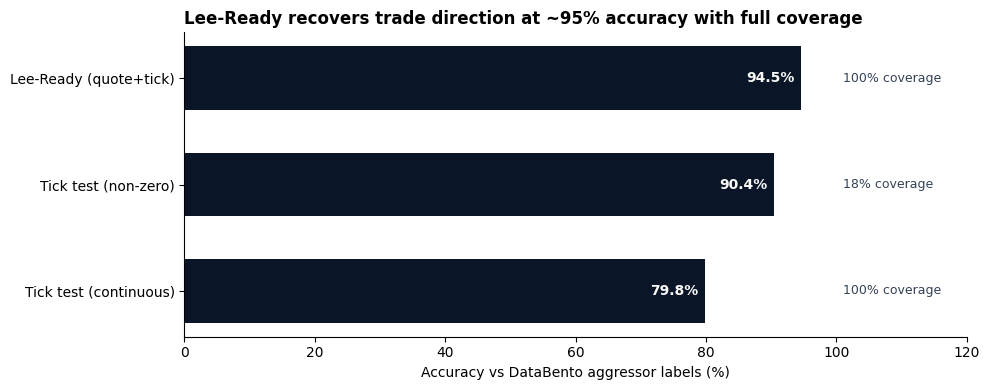

In [16]:
if "multi_day_tick_summary" in globals():
    _s = multi_day_tick_summary.sort("accuracy_pct")
    _methods = _s["method"].to_list()
    _acc = _s["accuracy_pct"].to_list()
    _cov = _s["coverage_pct"].to_list()

    fig, ax = plt.subplots(figsize=(10, 4), layout="tight")
    bars = ax.barh(_methods, _acc, color=COLORS["blue"], height=0.6)
    for bar, acc, cov in zip(bars, _acc, _cov):
        y = bar.get_y() + bar.get_height() / 2
        ax.text(
            acc - 1.0,
            y,
            f"{acc:.1f}%",
            va="center",
            ha="right",
            color=COLORS["silver"],
            fontweight="bold",
        )
        ax.text(
            101,
            y,
            f"{cov:.0f}% coverage",
            va="center",
            ha="left",
            color=COLORS["neutral"],
            fontsize=9,
        )
    ax.set_xlim(0, 120)
    ax.set_xlabel("Accuracy vs DataBento aggressor labels (%)")
    ax.set_title(
        "Lee-Ready recovers trade direction at ~95% accuracy with full coverage",
        loc="left",
        fontweight="bold",
    )
    ax.spines[["top", "right"]].set_visible(False)
    plt.show()

## Key Takeaways

### Lee-Ready Validation Results

| Method | Accuracy | Notes |
|--------|----------|-------|
| Lee-Ready (quote + tick) | ~94-95% | Uses LOB midpoint when available |
| Tick test only | ~78% | Significantly worse without quote test |
| Ground truth | 100% | DataBento provides actual aggressor |

### Why Lee-Ready Works

The quote test (comparing trade price to midpoint) captures the fundamental
market microstructure: buyer-initiated trades tend to occur at or above the ask
(above midpoint), while seller-initiated trades occur at or below the bid.

### Implementation Notes

1. **LOB state matters**: Must maintain accurate book state at each trade
2. **Tick test fallback**: Only used when trade exactly at midpoint
3. **Zero-tick handling**: Preserve last direction on unchanged price

---

**Reference**: Lee & Ready (1991), "Inferring Trade Direction from Intraday Data"